**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 1 — Datos (ETL)

Precios ajustados → series mensuales → retornos. Ventana ene-2016 → sep-2026.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT/'src'))
import portfolio_utils as pu
tickers = sorted(set(list(pu.CURRENT_WEIGHTS)+[pu.BENCHMARK]))
print('Tickers:', tickers)
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily).loc[:'2026-09-30']
print(monthly.index.min().date(), '→', monthly.index.max().date(), '| meses:', len(monthly))
rets = monthly.pct_change().loc['2016-01-31':'2026-09-30']
print('Retornos shape:', rets.shape)


Tickers: ['BRK-B', 'IEMG', 'SMH', 'SPY', 'SPYG', 'VTI']
2015-11-30 → 2026-09-30 | meses: 131
Retornos shape: (129, 6)


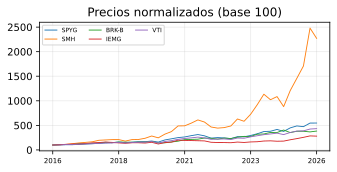

In [1]:
norm = monthly.loc['2016-01-31':, list(pu.CURRENT_WEIGHTS)].dropna()
norm = norm / norm.iloc[0] * 100
ax = norm.plot(figsize=(9,4), title='Precios normalizados (base 100)')
ax.set_ylabel('Índice'); plt.tight_layout(); plt.show()


## Conclusiones
1. ETL reproducible vía `portfolio_utils`.
2. Frecuencia mensual alineada con el backtest educativo.

## Ejercicios
1. Compara IEMG vs SPYG en 2022–2023.
2. Correlación VTI vs SPY.
